## Partie 2 : Définition et prédiction des sécheresses extrêmes à partir du SWI uniforme

L'objective est d'identifier les périodes et zones de sécheresse extrême à l’aide de différentes définitions statistiques.

Cette partie se concentre sur la caractérisation des événements hydriques les plus critiques. Pour ce faire, un critère de sécheresse extrême a été établi : **une commune est classée en état de crise si son SWI uniforme est inférieur au 5e percentile historique de son trimestre respectif**. Cette approche permet d'isoler les phénomènes de stress hydrique rares et d'une intensité exceptionnelle. La cartographie ci-dessous illustre la répartition spatiale des épisodes de sécheresse extrême identifiés selon le critère du 5e percentile historique.


**Calcul des Seuils Statistiques, le 5e percentile**

In [1]:
import pandas as pd
import geopandas as gpd

gdf_final = gpd.read_parquet("base_complete.geoparquet")

In [2]:


# 1. On définit les trimestres (ex: Q2 = Avril, Mai, Juin)
# Assurez-vous d'avoir une colonne 'TRIMESTRE' ou créez-la
gdf_final['TRIMESTRE'] = gdf_final['DATE_quot'].dt.quarter

# 2. Calcul du 25ème percentile par commune et par trimestre
# Cela crée une référence historique propre à chaque lieu
thresholds = gdf_final.groupby(['code_insee_de_la_region', 'TRIMESTRE'])['SWI_UNIF_MENS'].quantile(0.05).reset_index()
thresholds.rename(columns={'SWI_UNIF_MENS': 'SEUIL_Q25'}, inplace=True)

# 3. Fusion de ces seuils avec la base principale
df_model = gdf_final.merge(thresholds, on=['code_insee_de_la_region', 'TRIMESTRE'])

# 4. Création de la variable cible binaire (Label)
# 1 = Sécheresse Extrême (SWI < Seuil), 0 = Normal
df_model['IS_EXTREME_DROUGHT'] = (df_model['SWI_UNIF_MENS'] < df_model['SEUIL_Q25']).astype(int)

df_model.head()

,LAMBX,LAMBY,DATE_quot,PRENEI_MENS,PRELIQ_MENS,PRETOTM_MENS,T_MENS,EVAP_MENS,ETP_MENS,PE_MENS,...,geometry,SWI_UNIF_MENS,NIVEAU,code_insee,codes_insee_des_arrondissements,code_insee_du_departement,code_insee_de_la_region,TRIMESTRE,SEUIL_Q25,IS_EXTREME_DROUGHT
0,840,24010,2020-01,0.0,127.1,127.1,8.3,17.2,14.6,109.9,...,POINT (135448.614 6838590.367),1.055,1.0,2927,291,29,53,1,0.863,0
1,840,24010,2020-02,0.0,173.7,173.7,9.1,29.7,21.9,144.0,...,POINT (135448.614 6838590.367),1.095,1.0,2927,291,29,53,1,0.863,0
2,840,24010,2020-03,0.0,72.9,72.9,8.4,38.2,42.4,34.7,...,POINT (135448.614 6838590.367),1.032,1.0,2927,291,29,53,1,0.863,0
3,840,24010,2020-04,0.0,71.7,71.7,12.1,61.5,72.5,10.2,...,POINT (135448.614 6838590.367),0.778,1.0,2927,291,29,53,2,0.304,0
4,840,24010,2020-05,0.0,21.2,21.2,14.5,94.0,123.1,-72.8,...,POINT (135448.614 6838590.367),0.694,1.0,2927,291,29,53,2,0.304,0


**Réalisation du critère de sécheresse**

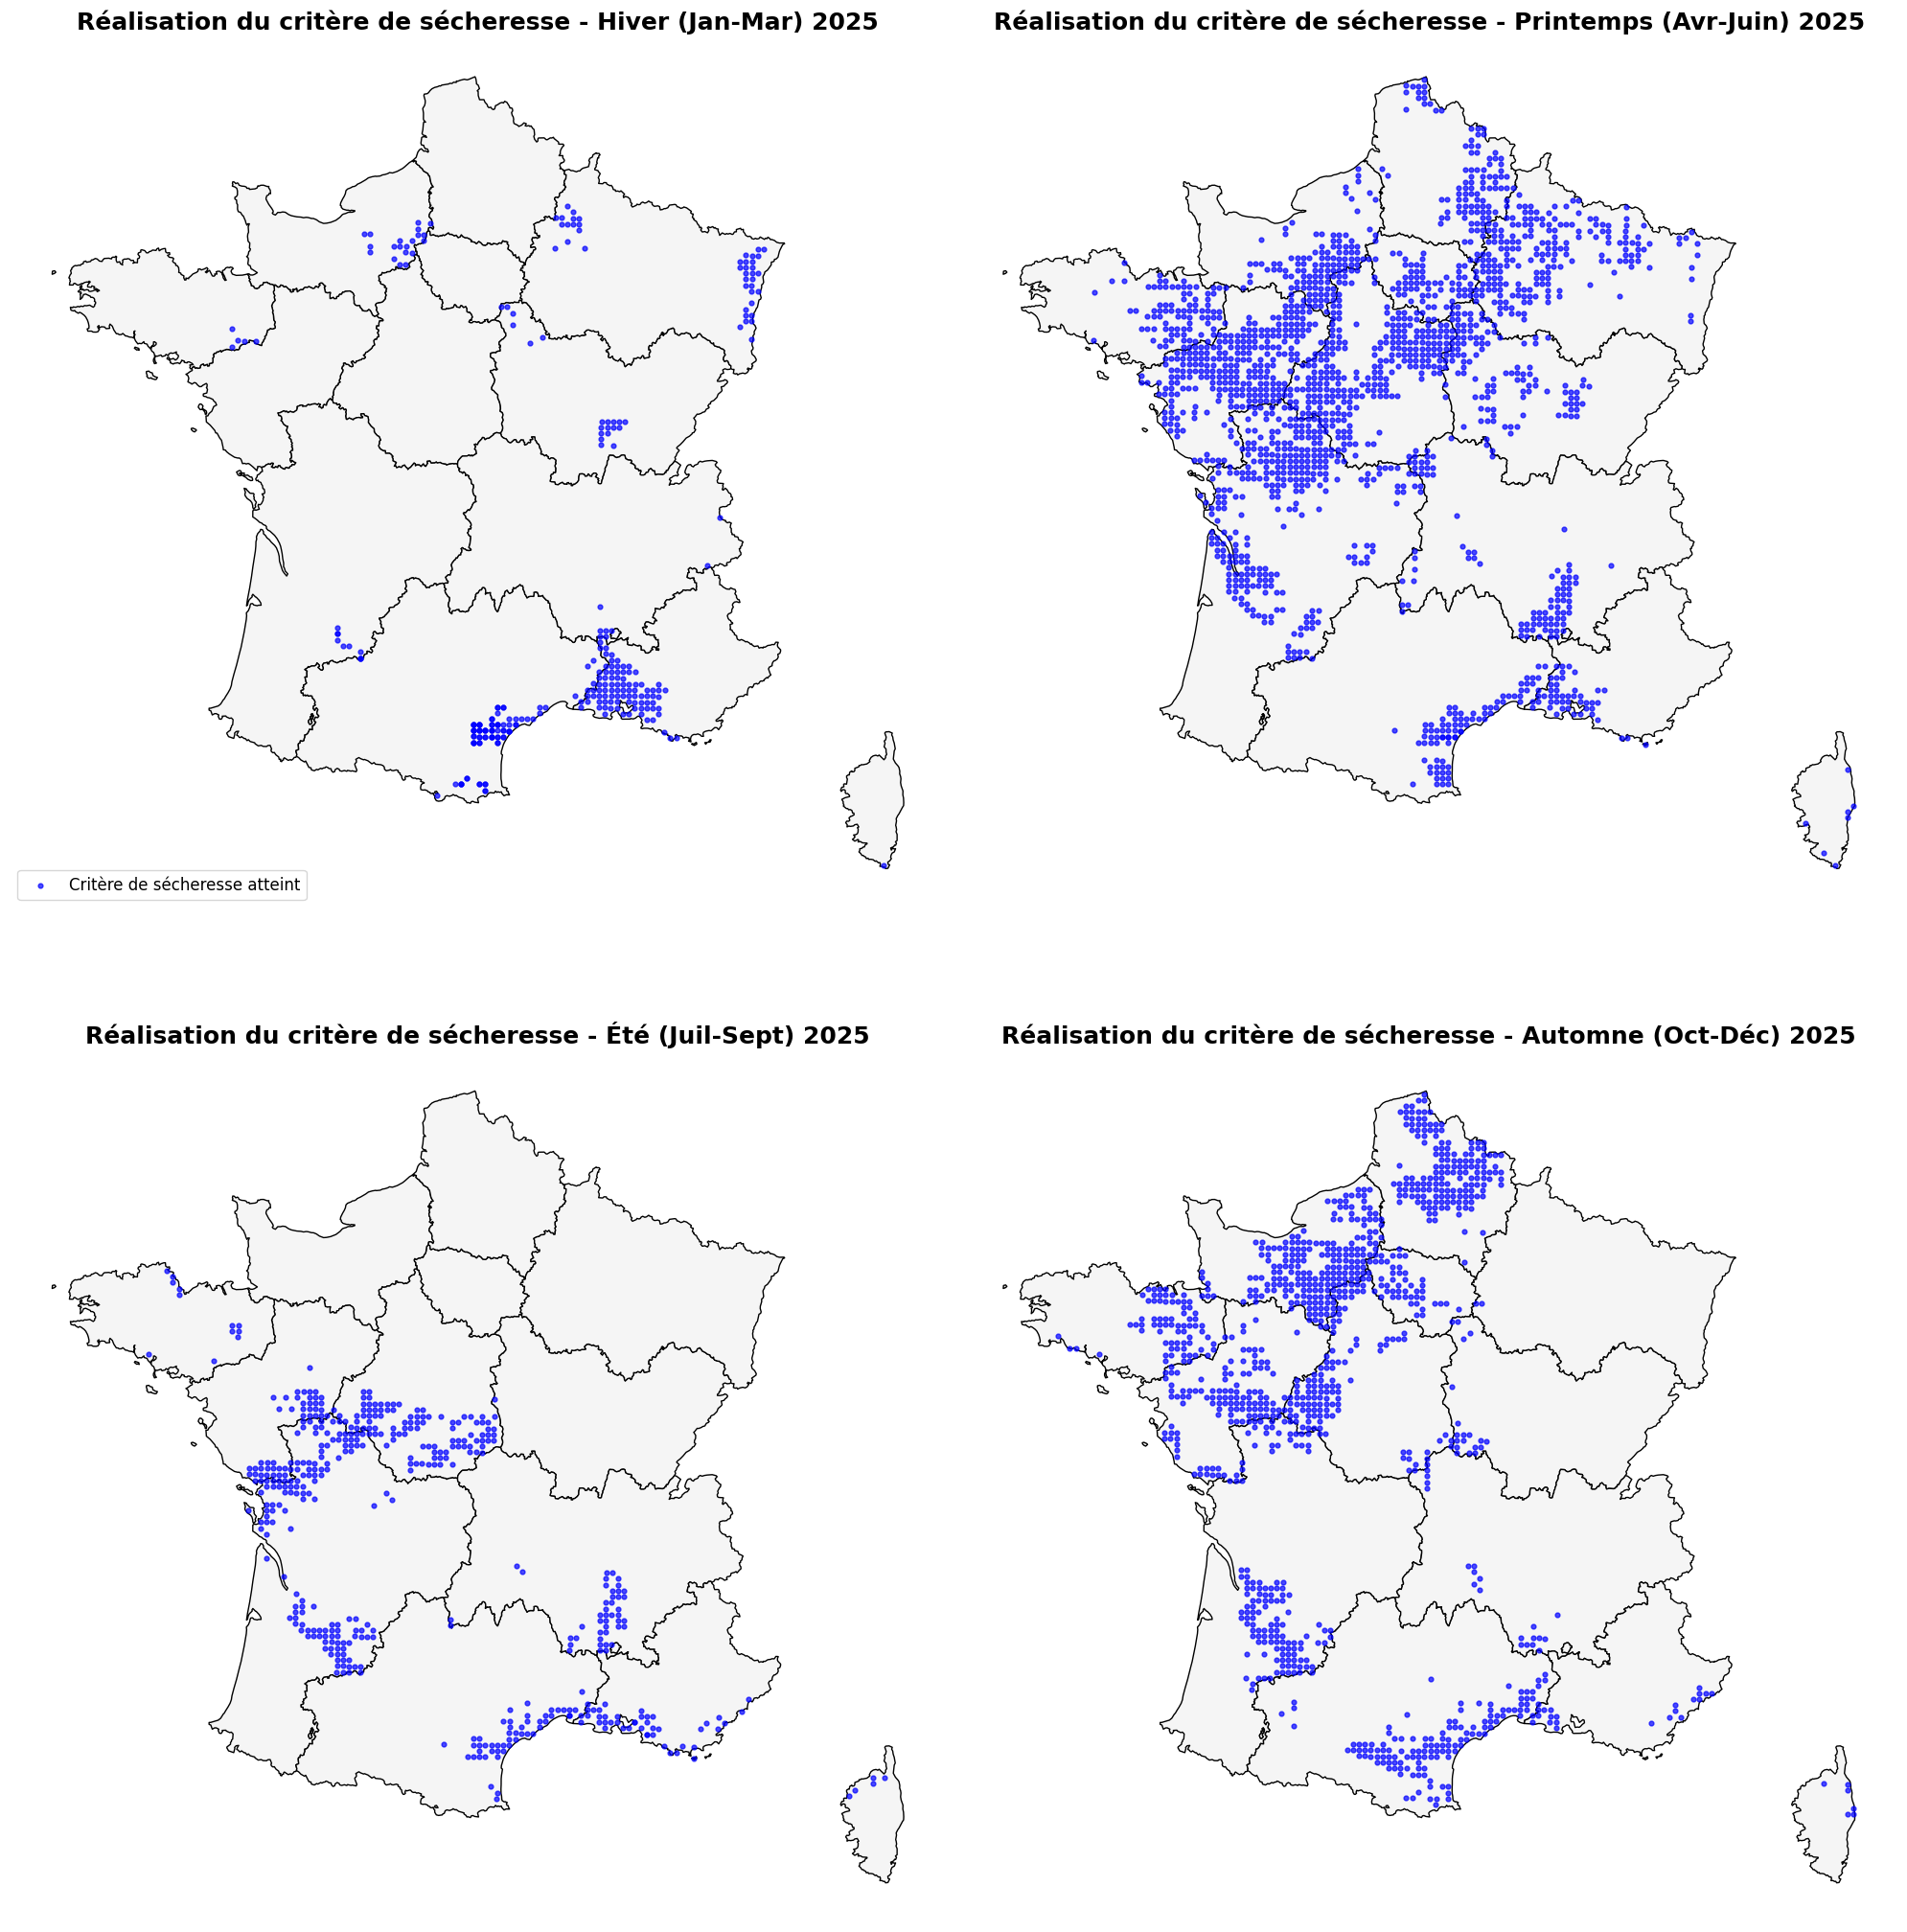

In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Chargement des limites des régions de France (Source : OpenData / Gregoire David)
# Ce GeoJSON contient les tracés précis des régions françaises
url_regions = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/regions-version-simplifiee.geojson"
regions = gpd.read_file(url_regions)

# 2. Alignement des systèmes de coordonnées (CRS)
# On s'assure que la carte des régions utilise le même système que vos données (ex: Lambert 93)
if df_model.crs is not None:
    regions = regions.to_crs(df_model.crs)

# 3. Préparation des données pour l'année 2025
df_model['ANNEE'] = df_model['DATE_quot'].dt.year
df_2025 = df_model[df_model['ANNEE'] == 2025].copy()

saisons = {
    1: "Hiver (Jan-Mar)",
    2: "Printemps (Avr-Juin)",
    3: "Été (Juil-Sept)",
    4: "Automne (Oct-Déc)"
}

# 4. Création de la figure (2 lignes, 2 colonnes)
fig, axes = plt.subplots(2, 2, figsize=(20, 22))
axes = axes.flatten()

for i, (trim, nom) in enumerate(saisons.items()):
    # A. Affichage du fond de carte avec les régions délimitées
    # 'edgecolor' trace les frontières en noir, 'facecolor' laisse l'intérieur neutre
    regions.plot(ax=axes[i], color='#f5f5f5', edgecolor='black', linewidth=1, zorder=1)
    
    # B. Filtrage des données pour le trimestre en cours
    data_trim = df_2025[df_2025['TRIMESTRE'] == trim]
    
    # C. Affichage des points en état de "Sécheresse Extrême"
    data_extreme = data_trim[data_trim['IS_EXTREME_DROUGHT'] == 1]
    
    if not data_extreme.empty:
        data_extreme.plot(
            ax=axes[i], 
            color='blue', 
            markersize=12, 
            alpha=0.7, 
            label='Critère de sécheresse atteint',
            zorder=2
        )
    
    # D. Habillage de la carte
    axes[i].set_title(f"Réalisation du critère de sécheresse - {nom} 2025", fontsize=18, fontweight='bold')
    axes[i].axis('off')
    if i == 0: # Légende uniquement sur la première carte pour ne pas surcharger
        axes[i].legend(loc='lower left', fontsize=12)

plt.tight_layout()
plt.savefig("drought_seasons_2025_regions.png", dpi=300)

Cette visualisation met en évidence une vulnérabilité persistante du pourtour méditerranéen et de la Corse (Codes 93 et 94), tout en révélant des poches de sécheresse extrême surprenantes dans le Grand Est dès l'hiver. L'extension du critère au printemps et à l'été montre une propagation du stress vers les régions de l'Ouest, confirmant que le seuil du 5e percentile capte efficacement les ruptures hydriques majeures sur l'ensemble du territoire.